<a href="https://colab.research.google.com/github/ArielaLevkov/ImageProcessing_TA/blob/main/exercises/ImageProcessingEx_01_HistogramEqualization_solved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div dir="rtl">

# מטלה 1 - פתרון:

<dir>

In [1]:
import os
import requests
from io import BytesIO
import numpy as np
import matplotlib.pyplot as plt
import PIL

In [2]:
GITHUB_PATH = 'https://raw.githubusercontent.com/ArielaLevkov/ImageProcessing_TA/main/images/'

def read_file(file_name:str, file_path:str=GITHUB_PATH) -> np.ndarray:
    '''
    Accept an image file name (defaulty located in GitHub) and return the image
    in a numpy array.

    Args:
        file_name: the file name
        file_path: the file path.. Default value is Doron's Github repo.

    Returns:
        the image converted into a Numpy array.
    '''
    file_path = os.path.join(file_path, file_name)
    response = requests.get(file_path)
    fp = BytesIO(response.content)

    img_pil = PIL.Image.open(fp)
    return np.array(img_pil, dtype='int16')

In [3]:
img = read_file(file_name='house.tiff')

In [4]:
def plot_img(img: np.array, figsize:(int,int)=None):
    if figsize:
        plt.figure(figsize = figsize)
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)

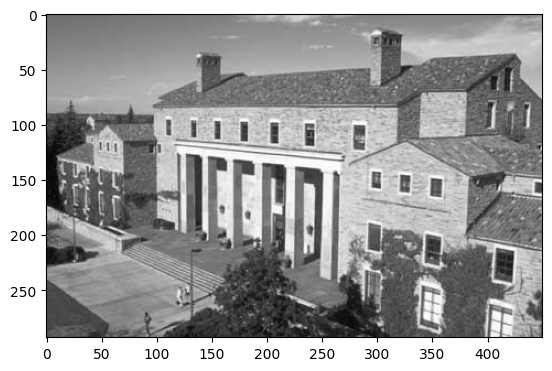

In [5]:
plot_img(img)

In [6]:
def get_normalized_hist(img: np.array) -> np.array:
    '''
    This function receive an image and returns its normalized accumulated
    histogram.
    Args:
        img: image in int16 format

    Returns:
        normalized_acc_hist: vector of normalized accumulated histogram.
    '''
    nrows, ncols = img.shape
    # get the image histogram
    hist = np.zeros(256)
    for r in range(nrows):
      for c in range(ncols):
        ind = img[r, c]
        hist[ind] = hist[ind] + 1

    # accumulated histomgram
    acc_hist = hist;
    for i in range(1, 256):
      acc_hist[i] = hist[i] + acc_hist[i-1];

    # normalized accumulated histogram
    normalized_acc_hist = acc_hist / (nrows * ncols)
    return normalized_acc_hist

In [7]:
def hist_shape(img_src: np.array, img_dest: np.array) -> np.array:
    '''
    This function perform an grayscale image enhancement using Histogram
    Equalization.
    Args:
        img_src: image in int16 format - the image to enhance
        img_dest: image in int16 format - the histogram will be based on it.

    Returns:
        img_new: Returned image, in int16 format - the enhanced image
    '''

    ######################################################################
    # TODO: Implement image enhancement using histogram Equalization.
    ######################################################################
    acc_hist_src = get_normalized_hist(img_src)
    acc_hist_dest = get_normalized_hist(img_dest)
    idx_src = 0
    idx_dest = 0

    # create a conversion vector to hold the new grayscale transformation
    cv = np.zeros(256, dtype=np.uint16)
    while idx_src < 256:
      if acc_hist_dest[idx_dest] < acc_hist_src[idx_src]:
        idx_dest = idx_dest + 1
      else:
        cv[idx_src] = idx_dest
        idx_src = idx_src + 1

    #create the new image according to the grayscale transformation vector
    nrows, ncols = img_src.shape
    img_new = np.zeros((nrows, ncols), dtype=np.int16)
    for r in range(nrows):
      for c in range(ncols):
        img_new[r, c] = cv[img_src[r, c]]
    ######################################################################
    #                            END OF YOUR CODE                        #
    ######################################################################

    return img_new

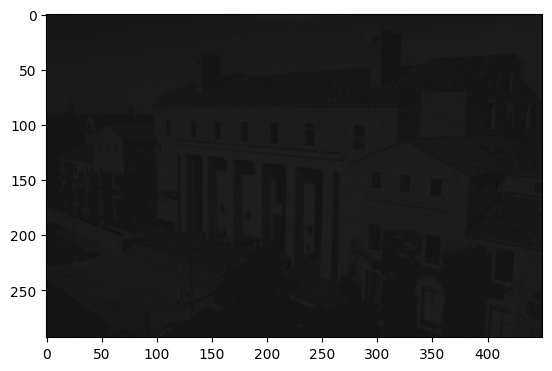

In [8]:
img_src = read_file(file_name='darkimage.tiff')
plot_img(img_src)

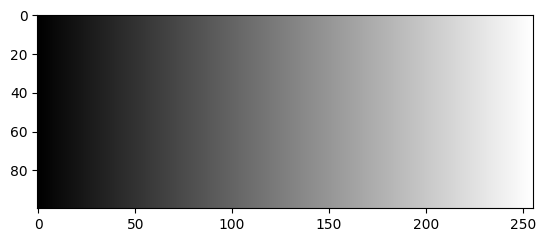

In [9]:
img_dest = read_file(file_name='flatHistShape.tiff')
plot_img(img_dest)

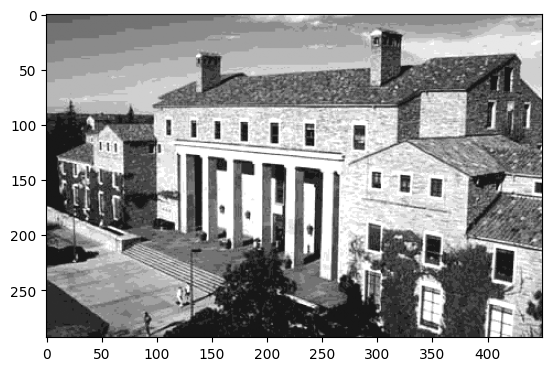

In [10]:
img_new = hist_shape(img_src, img_dest)
plot_img(img_new)

(1140, 750)


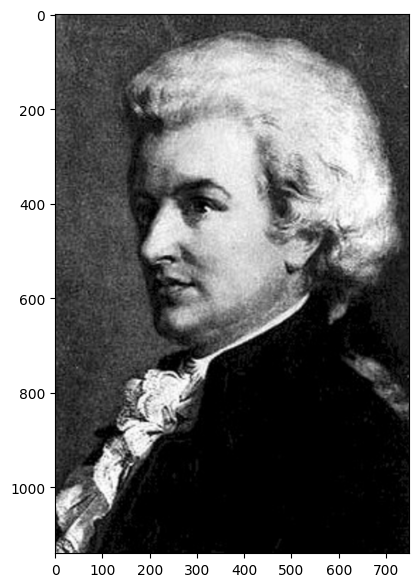

In [11]:
img_big = read_file(file_name='bigMozart.tiff')
print(img_big.shape)
plot_img(img_big, figsize=(7,7))

(38, 25)


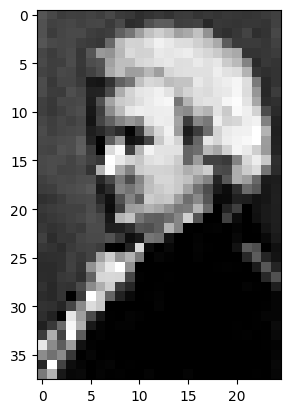

In [12]:
img_small = read_file(file_name='smallMozart.tiff')
print(img_small.shape)
plot_img(img_small)

In [13]:
def create_tiled_image(img_big: np.array, img_small: np.array) -> np.array:
    '''
    This function receives 2 grayscale image (matrix of int16, values:0..255) and
    creates a new image. The new image consists of tiles of the small image
    which forms the big image. Each of the small image tiles is processed using
    the histShape function to match the histogram of the big image in the same
    location.
    Args:
        img_big: image in int16 format - the image to enhance
        img_small: image in int16 format - the histogram will be based on it.

    Returns:
        img_new: returned image, in int16 format - the tiled image
    '''

    ######################################################################
    # TODO: Implement tiles image using histogram Equalization.
    ######################################################################

    # Replace "pass" statement with your code
    nrows_big, ncols_big = img_big.shape
    nrows_small, ncols_small = img_small.shape
    img_new = np.zeros((nrows_big, ncols_big), dtype=np.int16)
    for r in range(0, nrows_big, nrows_small):
        for c in range(0, ncols_big, ncols_small):
            img_new[r:r+nrows_small, c:c+ncols_small] = hist_shape(
                img_small, img_big[r:r+nrows_small, c:c+ncols_small])
    ######################################################################
    #                            END OF YOUR CODE                        #
    ######################################################################

    return img_new

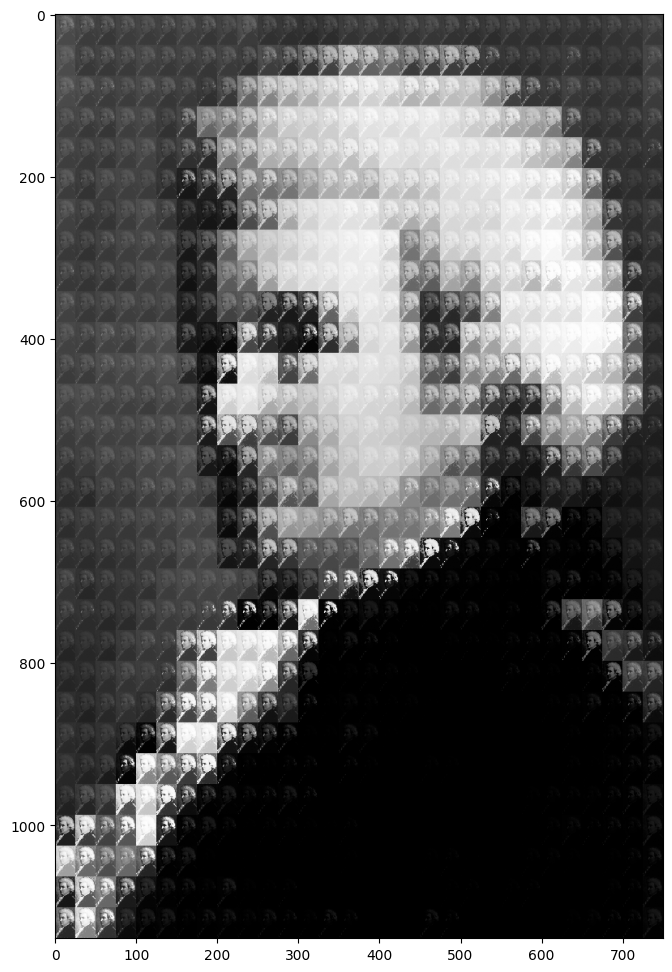

In [14]:
img_new = create_tiled_image(img_big, img_small)
plot_img(img_new, figsize=(12,12))